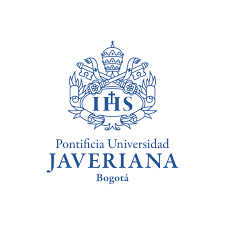
***Pontificial Xaverian  University***
# **Big Data Processment**

### Topic: **Metrics y Machine Learning with PySpark**

Autor: Diego Alejandro Sarmiento Rodriguez

Starting Date: April 28th - 2026
Final Date:  May 25th - 2026



### **Goal**: Implement Spark Machine learning classification models, using the complete Data treatment process
#### **Case:** Client behavior with a fixed term loan, The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution.
#### **Dataset:** [Uc Urvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

#### **Table of contents::**
- Load Spark session.
- Load Bank data.
- Data understanding and description.
- Data cleaning and treatment.
- Metrics (ROC curve and Confussion Matrix).
- Machine learning algorithms (Logistic regression, Random forest, Desicion tree, Gradient boosting tree (GBT), Support Vector Machine (SVM)).
- Model evaluation.
- Conclusions.

In [1]:
## Import basic libraries
import os
import sys                             #---> Provides the interpreter access to some variables
import pandas as pd                    #---> For dataframes and plotting
import numpy as np                     #---> For mathematical operations
import matplotlib.pyplot as plt        #---> For visualization formatting
import seaborn as sns

## Specialized libraries import
import findspark                       #---> Locates Spark to add it to the python path
findspark.init()
from pyspark.sql import SQLContext, SparkSession, Row            #---> Session for SQL-based query environments
from pyspark import SparkContext, SparkConf     #---> PySpark context and configuration
from pyspark.sql import functions as F
from pyspark.sql.types import *

## Machine Learning libraries import
from pyspark.ml.feature import StringIndexer, OneHotEncoder   #-> Provides access to variable preparation functions for ML
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

In [2]:
### Create Spark session
configura = SparkConf()

configura.setAppName("Metrics_Lab")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

# SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkS

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 22:16:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


## **IMPORT DATASET**

In [3]:
##**2.- Loading Data from HADOOP HDFS**
#!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

##The bank-full.csv file is loaded into a dataframe to manipulate the data   
df00 = sparkS.read.format("csv").option("header", "true",).option("sep",";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")
## The header of the table is displayed, showing only the first 5 values of the dataset
df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

## **DATA UNDERSTANDING AND DESCRIPTION**


In [4]:
##Columns
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [5]:
## Display the amount of data
print(f"Total number of records: {df00.count()}")

[Stage 2:=============================>                             (1 + 1) / 2]

Total number of records: 45211


## **VARIABLES DESCRIPTION**

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **age** | Feature | Integer | Age | Age of the client | Years | None |
| **job** | Feature | Categorical | Occupation | Type of job | None | 'unknown' |
| **marital** | Feature | Categorical | Marital Status | Marital status | None | 'unknown' |
| **education** | Feature | Categorical | Education Level | Education level | None | 'unknown' |
| **default** | Feature | Binary | None | Has credit in default? | None | None |
| **balance** | Feature | Integer | None | Average yearly balance | Euros | None |
| **housing** | Feature | Binary | None | Has housing loan? | None | None |
| **loan** | Feature | Binary | None | Has personal loan? | None | None |
| **contact** | Feature | Categorical | None | Contact communication type | None | 'unknown' / 'none' |
| **day_of_week** | Feature | Date | None | Last contact day of the week | None | None |
| **month** | Feature | Date | None | Last contact month of the year | None | None |
| **duration** | Feature | Integer | None | Last contact duration | Seconds | None |
| **campaign** | Feature | Integer | None | Number of contacts performed during this campaign | Contacts | None |
| **pdays** | Feature | Integer | None | Number of days passed after the client was last contacted | Days | '-1' (Not contacted) |
| **previous** | Feature | Integer | None | Number of contacts performed before this campaign | Contacts | None |
| **poutcome** | Feature | Categorical | None | Outcome of the previous marketing campaign | None | 'unknown' / 'nonexistent' |
| **y** | Target | Binary | None | Has the client subscribed to a term deposit? | None | None |

In [6]:
#**Principal statistics of the data:**

for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             45211|
|   mean| 40.93621021432837|
| stddev|10.618762040975401|
|    min|                18|
|    max|                95|
+-------+------------------+

+-------+-------+
|summary|    job|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min| admin.|
|    max|unknown|
+-------+-------+

+-------+--------+
|summary| marital|
+-------+--------+
|  count|   45211|
|   mean|    NULL|
| stddev|    NULL|
|    min|divorced|
|    max|  single|
+-------+--------+



+-------+---------+
|summary|education|
+-------+---------+
|  count|    45211|
|   mean|     NULL|
| stddev|     NULL|
|    min|  primary|
|    max|  unknown|
+-------+---------+

+-------+-------+
|summary|default|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min|     no|
|    max|    yes|
+-------+-------+

+-------+------------------+
|summary|           balance|
+-------+------------------+
|  count|             45211|
|   mean|1362.2720576850766|
| stddev|3044.7658291685243|
|    min|                -1|
|    max|              9997|
+-------+------------------+

+-------+-------+
|summary|housing|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min|     no|
|    max|    yes|
+-------+-------+

+-------+-----+
|summary| loan|
+-------+-----+
|  count|45211|
|   mean| NULL|
| stddev| NULL|
|    min|   no|
|    max|  yes|
+-------+-----+

+-------+--------+
|summary| contact|
+-------+--------+
|  count|   45211|
|   mean| 

## **VARIABLE CASTING**

In [7]:
# The following columns are changed to Integer
df01 = df00
df01 = df01.withColumn("age", df00.age.cast("int")) ## ---> The variable cast is performed in a dataset copy
df01 = df01.withColumn("balance", df00.balance.cast("int"))
df01 = df01.withColumn("day", df00.day.cast("int")) ## ---> From this point, a new copy is not made, but the same dataset is modified: "dfPy01"
df01 = df01.withColumn("duration", df00.duration.cast("int"))
df01 = df01.withColumn("campaign", df00.campaign.cast("int"))
df01 = df01.withColumn("pdays", df00.pdays.cast("int"))
df01 = df01.withColumn("previous", df00.previous.cast("int"))

df01.printSchema() ## ---> Display the Schema of data

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [8]:
col_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

for col in col_cat:
    df01.groupBy(col).count().show()     #---> Showing the balance of the categorical variables.

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

In [9]:
from pyspark.sql import functions as F

# Group and count
balance = df01.groupBy("y").count()

# Show results
balance.show()

# Calculate proportions
total = df01.count()
balance.withColumn("percentage", (F.col("count") / total) * 100).show()

+---+-----+
|  y|count|
+---+-----+
| no|39922|
|yes| 5289|
+---+-----+

+---+-----+------------------+
|  y|count|        percentage|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



### **COMMENTS**

* **Target Class Imbalance:** When analyzing the target variable `y`, a clear imbalance is evident toward the "no" option, which accounts for 88.3% of the dataset.
  * **Class "no"** -> 88.3% (39,922 records).
  * **Class "yes"** -> 11.7% (5,289 records).

* **Machine Learning Requirements:** To effectively train ML models, datasets should ideally maintain an 80-20 balance at the very least. Working with an 88.3% to 11.7% split introduces a severe bias, reducing the reliability and confidence of the models' predictions or groupings.

* **Recommendation:** It is highly recommended to address this class imbalance to improve overall model performance.

### **FRECUENCY TABLES: NUMERIC VARIABLES**

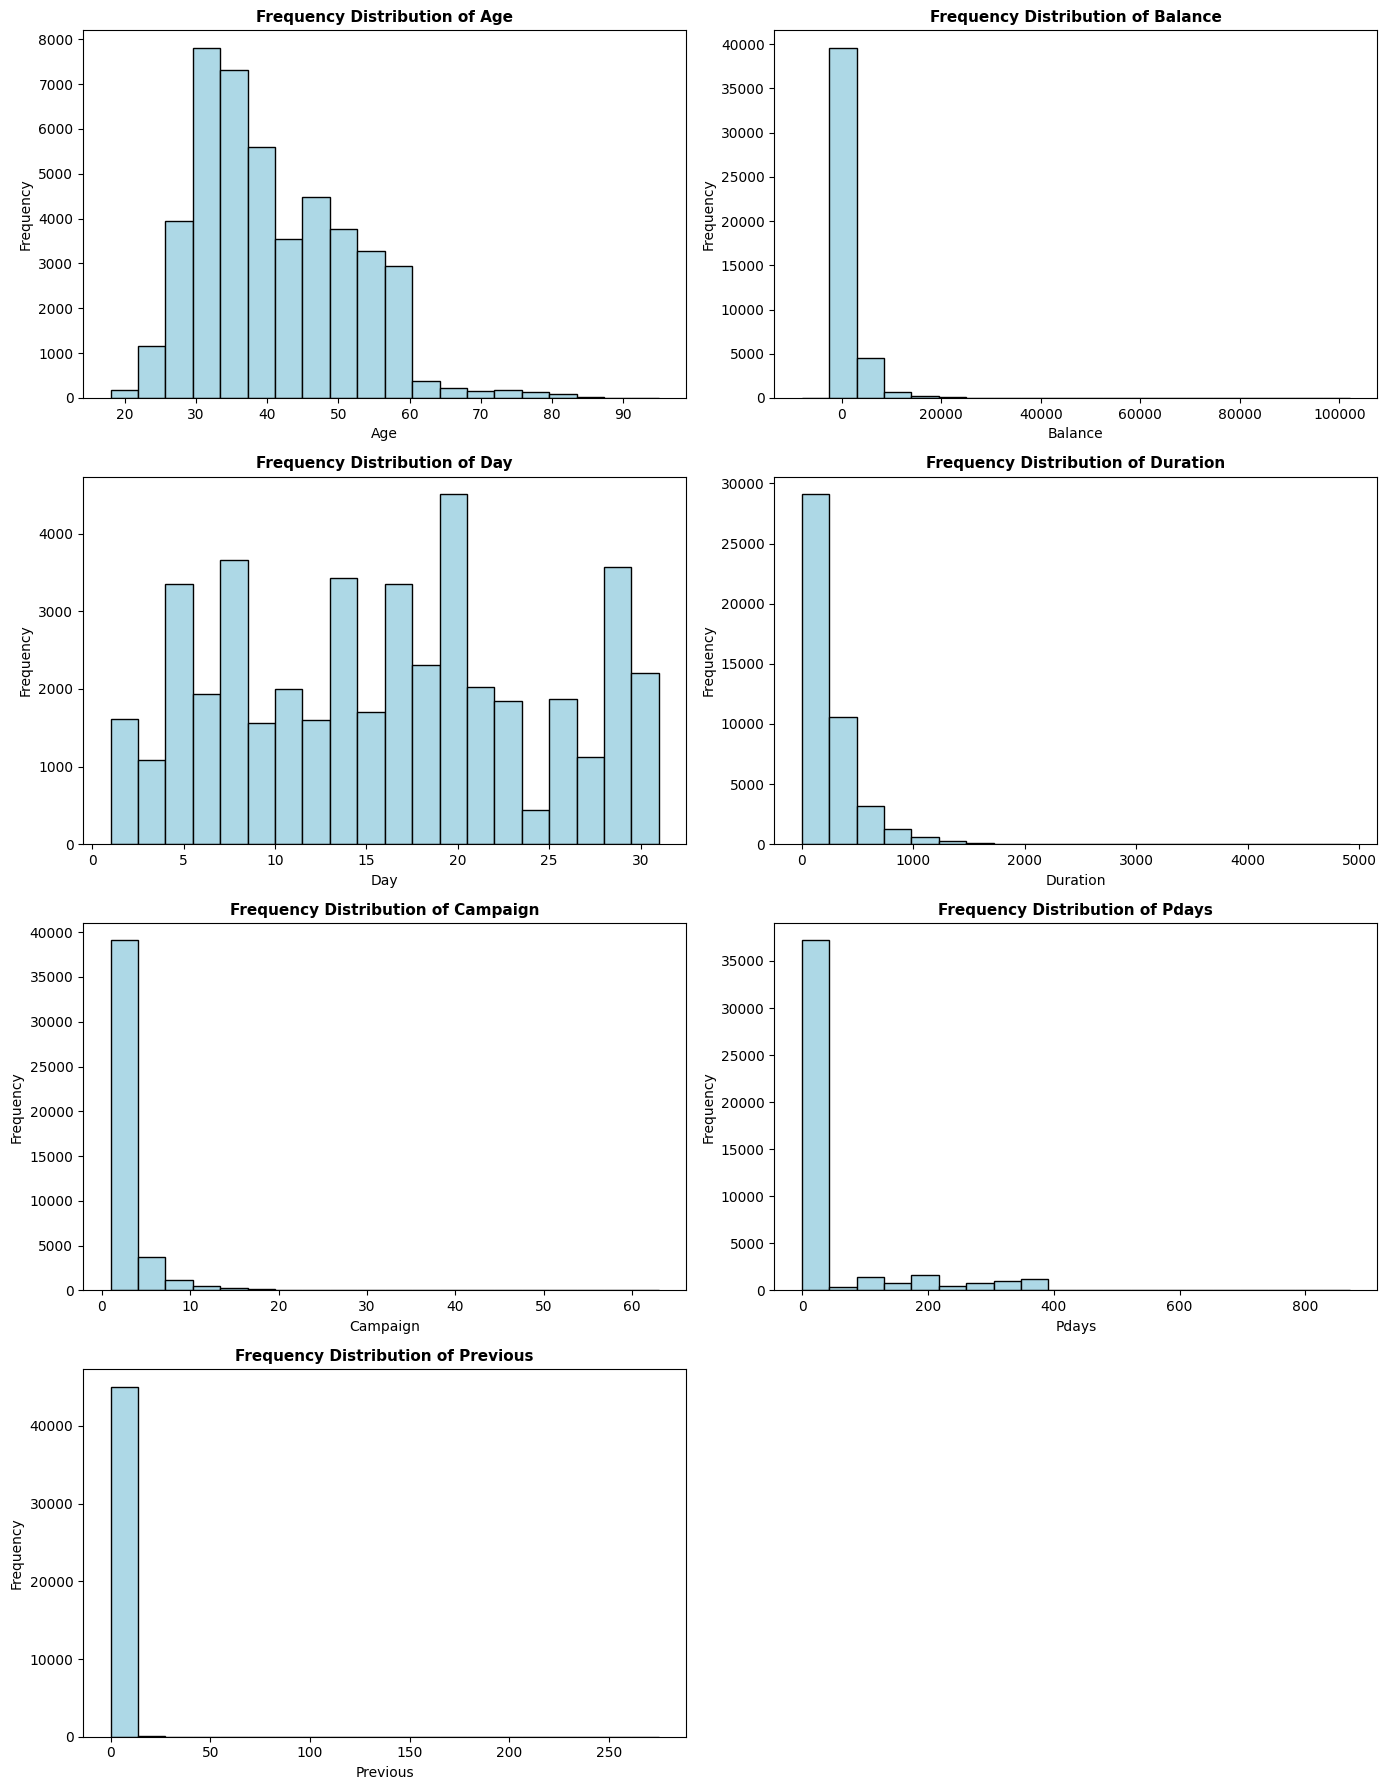

In [10]:
import matplotlib.pyplot as plt
colInt = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
# 1. Convert to Pandas once to optimize performance
df_pandas_num = df01.select(colInt).toPandas()


# 2. Create a grid layout (4 rows, 2 columns fits all 7 variables perfectly)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

# Flatten the axes grid array from 2D to 1D for easy looping
axes = axes.flatten()

# 3. Generate individual histograms in the grid
for i, col_int in enumerate(colInt):
    # Plot directly onto the specific grid slot using the 'ax' parameter
    df_pandas_num[col_int].plot(
        kind='hist', 
        bins=20, 
        edgecolor='black', 
        color='lightblue', 
        ax=axes[i]
    )
    
    # Set titles and labels for each subplot
    axes[i].set_title(f"Frequency Distribution of {col_int.capitalize()}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col_int.capitalize())
    axes[i].set_ylabel("Frequency")

# 4. Hide the 8th subplot slot since you only have 7 variables
axes[-1].set_visible(False)

# 5. Adjust spacing so titles and labels don't mash into each other
plt.tight_layout()
plt.show()

### **COMMENTS**

#### **1. Frequency Distribution of Age**
Observation: The distribution is unimodal and slightly right-skewed. The vast majority of targeted clients are between 25 and 60 years old, peaking significantly around the 30–40 age bracket. There is a sharp decline after age 60 (retirement age). Age is well-distributed and likely a strong predictor. 

#### **2. Frequency Distribution of Balance**
Observation: This distribution is extremely heavily right-skewed, centered tightly around 0 to 5,000 euros, with an extreme tail extending past 80,000 euros. There are also negative values representing clients with overdrafts. Maybe thisvalues can create extreme outliers problems.

#### **3. Frequency Distribution of Day**
Observation: The distribution of the day of the month when the contact was made is relatively uniform, though it shows cyclic peaks (e.g., around days 5, 8, 13, 18, 20, and 30) and a notable drop around day 25. This suggests marketing campaigns are executed in waves throughout the month.

#### **4. Frequency Distribution of Duration**
Observation: Heavily right-skewed. Most calls last only a few minutes (under 500 seconds), while a very small fraction last much longer (up to 4,000+ seconds).

#### **5. Frequency Distribution of Campaign**
Observation: Heavily right-skewed. This shows the number of contacts performed during this campaign for each client. The vast majority of clients were contacted only 1 to 3 times, but some extreme cases were contacted over 50 times.


#### **6. Frequency Distribution of Pdays**
Observation: This represents the number of days that passed after the client was last contacted from a previous campaign. There is a massive spike near 0 (or -1, typically used in this dataset to denote "never contacted before"). A smaller, secondary distribution appears between 100 and 400 days.


#### **7. Frequency Distribution of Previous**
Observation: This shows the number of contacts performed before this campaign. Mirroring the pdays chart, the overwhelming majority of the data is concentrated at 0 (never contacted before).


### **BOXPLOTS**

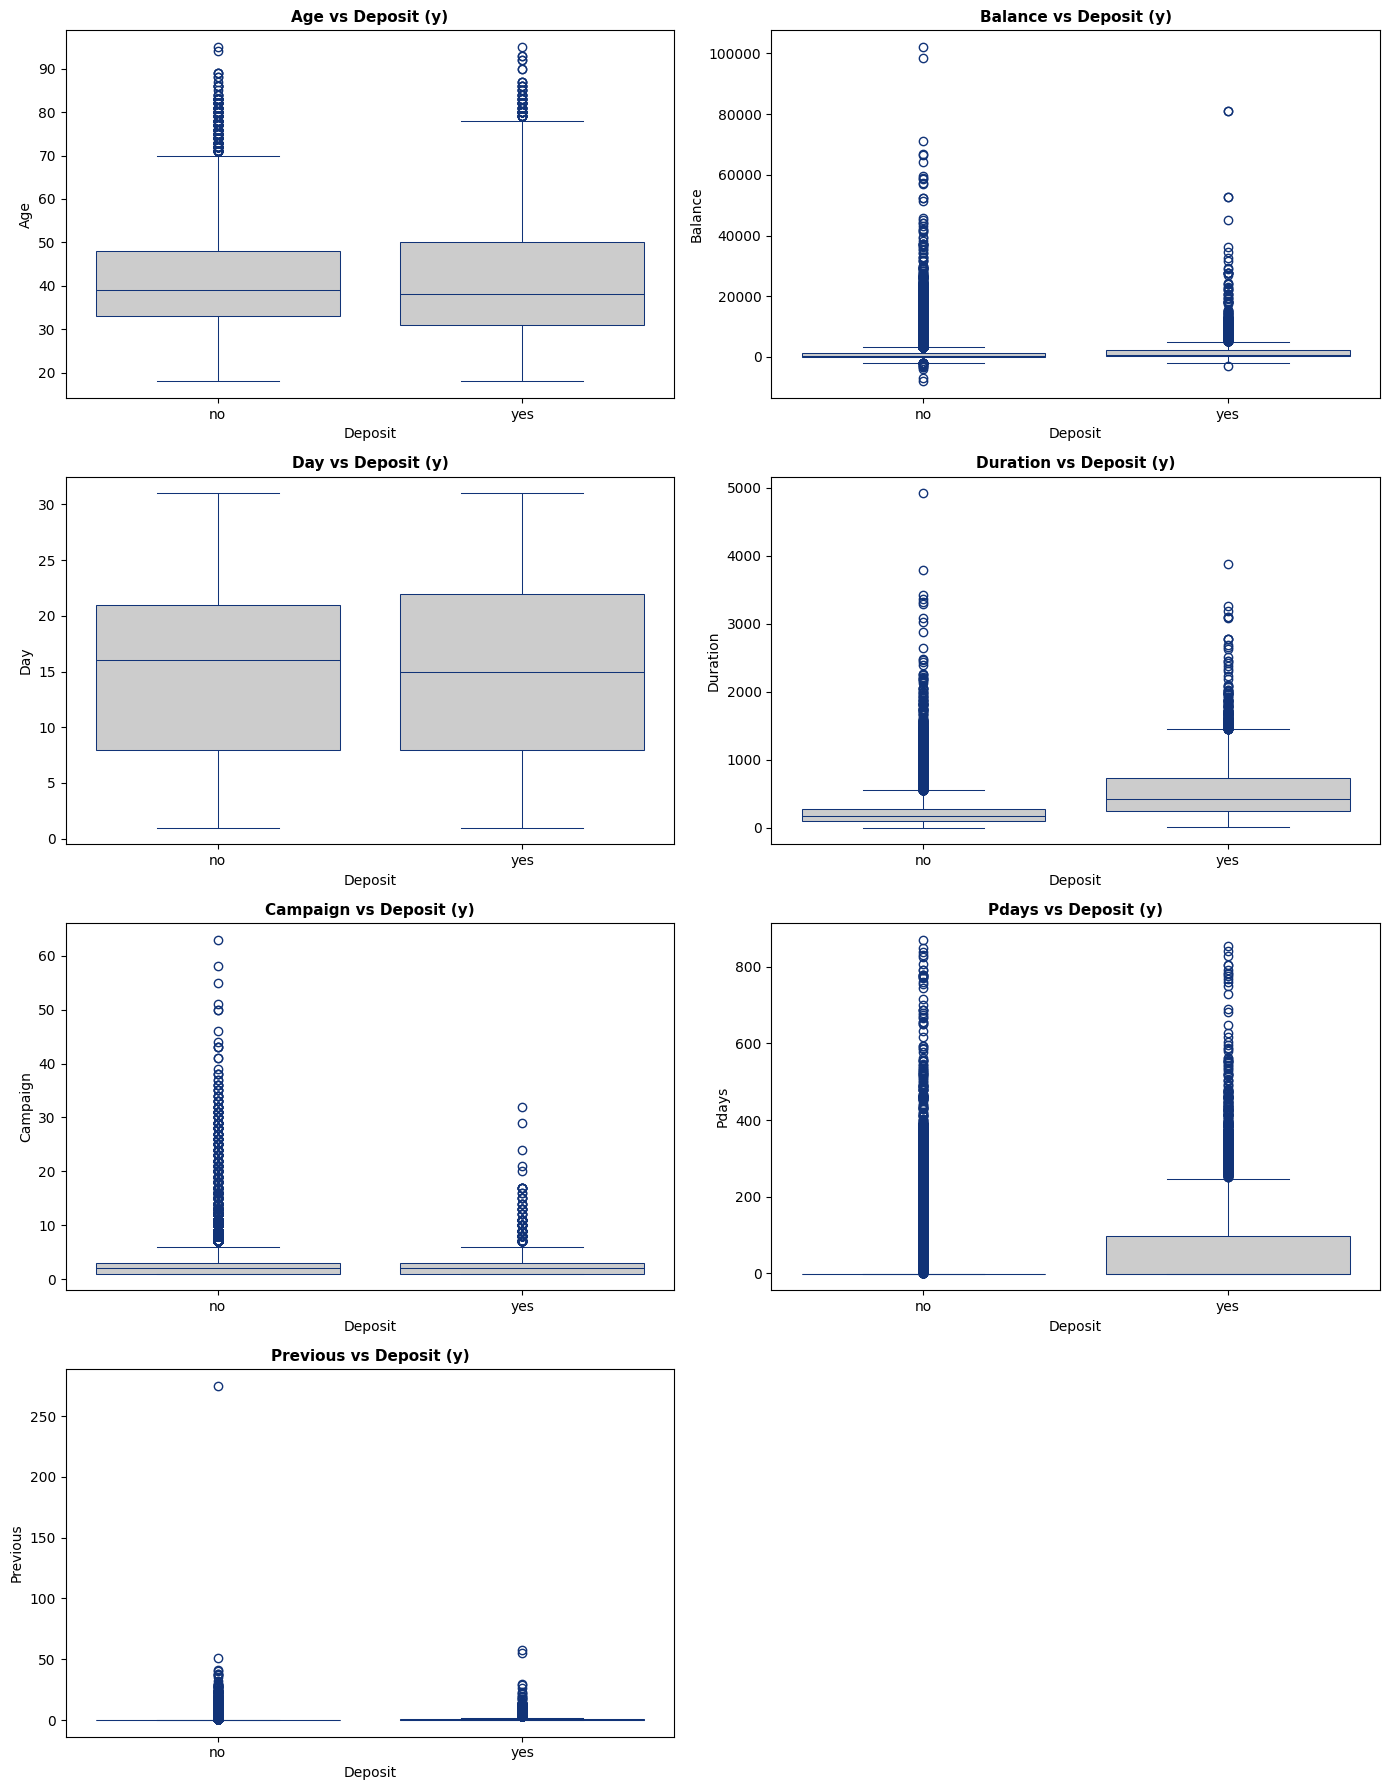

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the dataframe to Pandas once to avoid hitting the Spark cluster 7 times
df_pandas = df01.toPandas()

# Create a figure grid (4 rows, 2 columns to fit all 7 variables perfectly)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

# Flatten the axes array from 2D to 1D so we can loop through it easily
axes = axes.flatten()

# Generate the boxplot for each numeric variable
for i, col_int in enumerate(colInt):
    sns.boxplot(
        x='y', 
        y=col_int, 
        color=".8",
        linecolor="#137", 
        linewidth=0.75, 
        data=df_pandas, 
        ax=axes[i] # This tells seaborn to place the plot in the specific grid slot
    )
    axes[i].set_title(f"{col_int.capitalize()} vs Deposit (y)", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Deposit")
    axes[i].set_ylabel(col_int.capitalize())

# Hide the 8th subplot slot since you only have 7 variables
axes[-1].set_visible(False)

# Adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

## **COMMENTS**

#### **1. Age vs Deposit (y)**
Observation: The median, interquartile range (IQR), and overall distribution of age are remarkably similar for both the "yes" and "no" target classes. Both distributions are centered around a median age of late 30s, spanning primarily between 30 and 50 years old, with a similar pattern of older outliers extending up to age 90+ in both groups.

#### **2. Balance vs Deposit (y)**
Observation: The main bodies (IQRs) of both boxes are highly compressed near zero, indicating that most clients in both categories maintain low to moderate balances. However, the "no" group displays a significantly denser column of extreme positive outliers stretching up to 100,000, as well as a wider spread of negative balances, compared to the "yes" group.

#### **3. Day vs Deposit (y)**
Observation: The distribution of the day of the month when contact was made is virtually identical across both target classes. The median day sits consistently around day 15 to 16, and the overall spread of contacts spans evenly from day 1 to day 31 for both successful and unsuccessful campaigns.

#### **4. Duration vs Deposit (y)**
Observation: There is a distinct visual difference in call durations between the two groups. The median call duration for clients who subscribed ("yes") is noticeably higher than for those who did not ("no"), and the "yes" group has a much wider interquartile range, showing that successful outcomes are strongly associated with longer conversation lengths.

#### **5. Campaign vs Deposit (y)**
Observation: The "yes" group features a lower median and a much tighter distribution, indicating that clients who subscribe are generally reached within the first few contact attempts. In contrast, the "no" group contains a massive, dense vertical trail of outliers, highlighting a sub-segment of clients who were called repeatedly (up to 60+ times) without converting.

#### **6. Pdays vs Deposit (y)**
Observation: The boxplot for the "no" group is completely flattened at the bottom, showing that the vast majority of these clients have a value of 0 (or -1), meaning they were never contacted in a previous campaign. Conversely, the "yes" group shows a much taller box, indicating that a visible portion of subscribing clients had been contacted within the last 100 days.

#### **7. Previous vs Deposit (y)**
Observation: Due to the high volume of new prospects, the interquartile range for both groups is flattened near zero. However, the outlier patterns differ; the "no" group contains an extreme anomalous outlier reaching over 250 previous contacts, while the "yes" group's previous contact history tops out much lower, around 50.

## **CORRELATION MATRIX**

In [12]:
## It requires to change the target variable name
## Also, we need to change to numeric values



dfauxNum = df01.select(colInt + ['y']) #---> Creating new dataset
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes', 1).otherwise(0)) #---> Changing to Integer 'y' values
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [13]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')

# Normalized and Scaling Vector
dfNumVector = assembler.transform(dfauxNum).select('features')

Text(0.5, 1.0, 'Correlation Matrix within numeric variables and y variable')

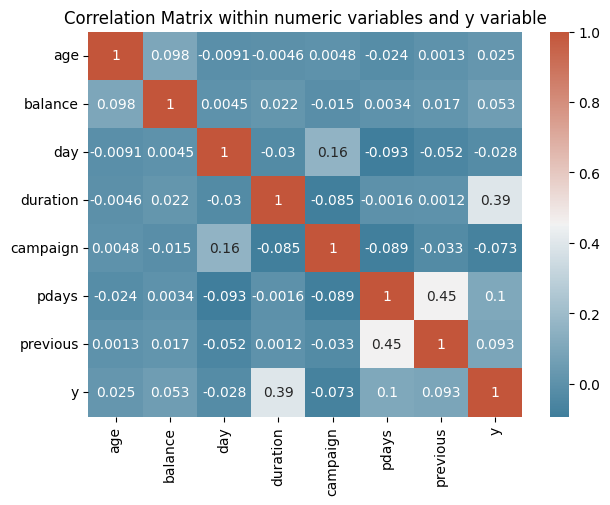

In [14]:
## Is graphed the correlation matrix
from pyspark.ml.stat import Correlation
corrMatrix = Correlation.corr(dfNumVector, 'features').head()

corrVector = corrMatrix[0].toArray()

## Is created a dataframe object using the previous Pearson Correlation array
dfCorrelation = pd.DataFrame(corrVector, columns = dfauxNum.columns, index=dfauxNum.columns)

cmapMendez = sns.diverging_palette(230, 20, as_cmap=True)
plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapMendez)
plt.title('Correlation Matrix within numeric variables and y variable')

### **COMMENTS**

#### **5 Good (Strongest) Correlations**

**These are the pairs that show the highest absolute correlation coefficients in the matrix, indicating the strongest linear relationships in your dataset**

- *pdays and previous (0.45)*: This is the strongest feature-to-feature correlation. A higher number of days since the last campaign contact (pdays) strongly correlates with having a higher number of total past contacts (previous).

- *duration and y (0.39)*: This is the strongest direct correlation to your target variable ($y$). It indicates that longer phone conversation lengths are strongly tied to a client subscribing to the term deposit.

- *day and campaign (0.16)*: A mild positive relationship, indicating that the number of contacts performed during this campaign tends to slightly increase during certain periods of the month (likely around specific payment or billing cycles).
pdays and y (0.10): A mild positive correlation showing that the time elapsed since a client was last contacted has a visible linear relationship with whether they accept the deposit offer.

- *previous and y (0.093)*: A weak-to-mild positive relationship showing that clients who have a history of being contacted in past marketing efforts are slightly more likely to say "yes" to the current campaign.


## **LARGE MATRIX OF PLOTS**

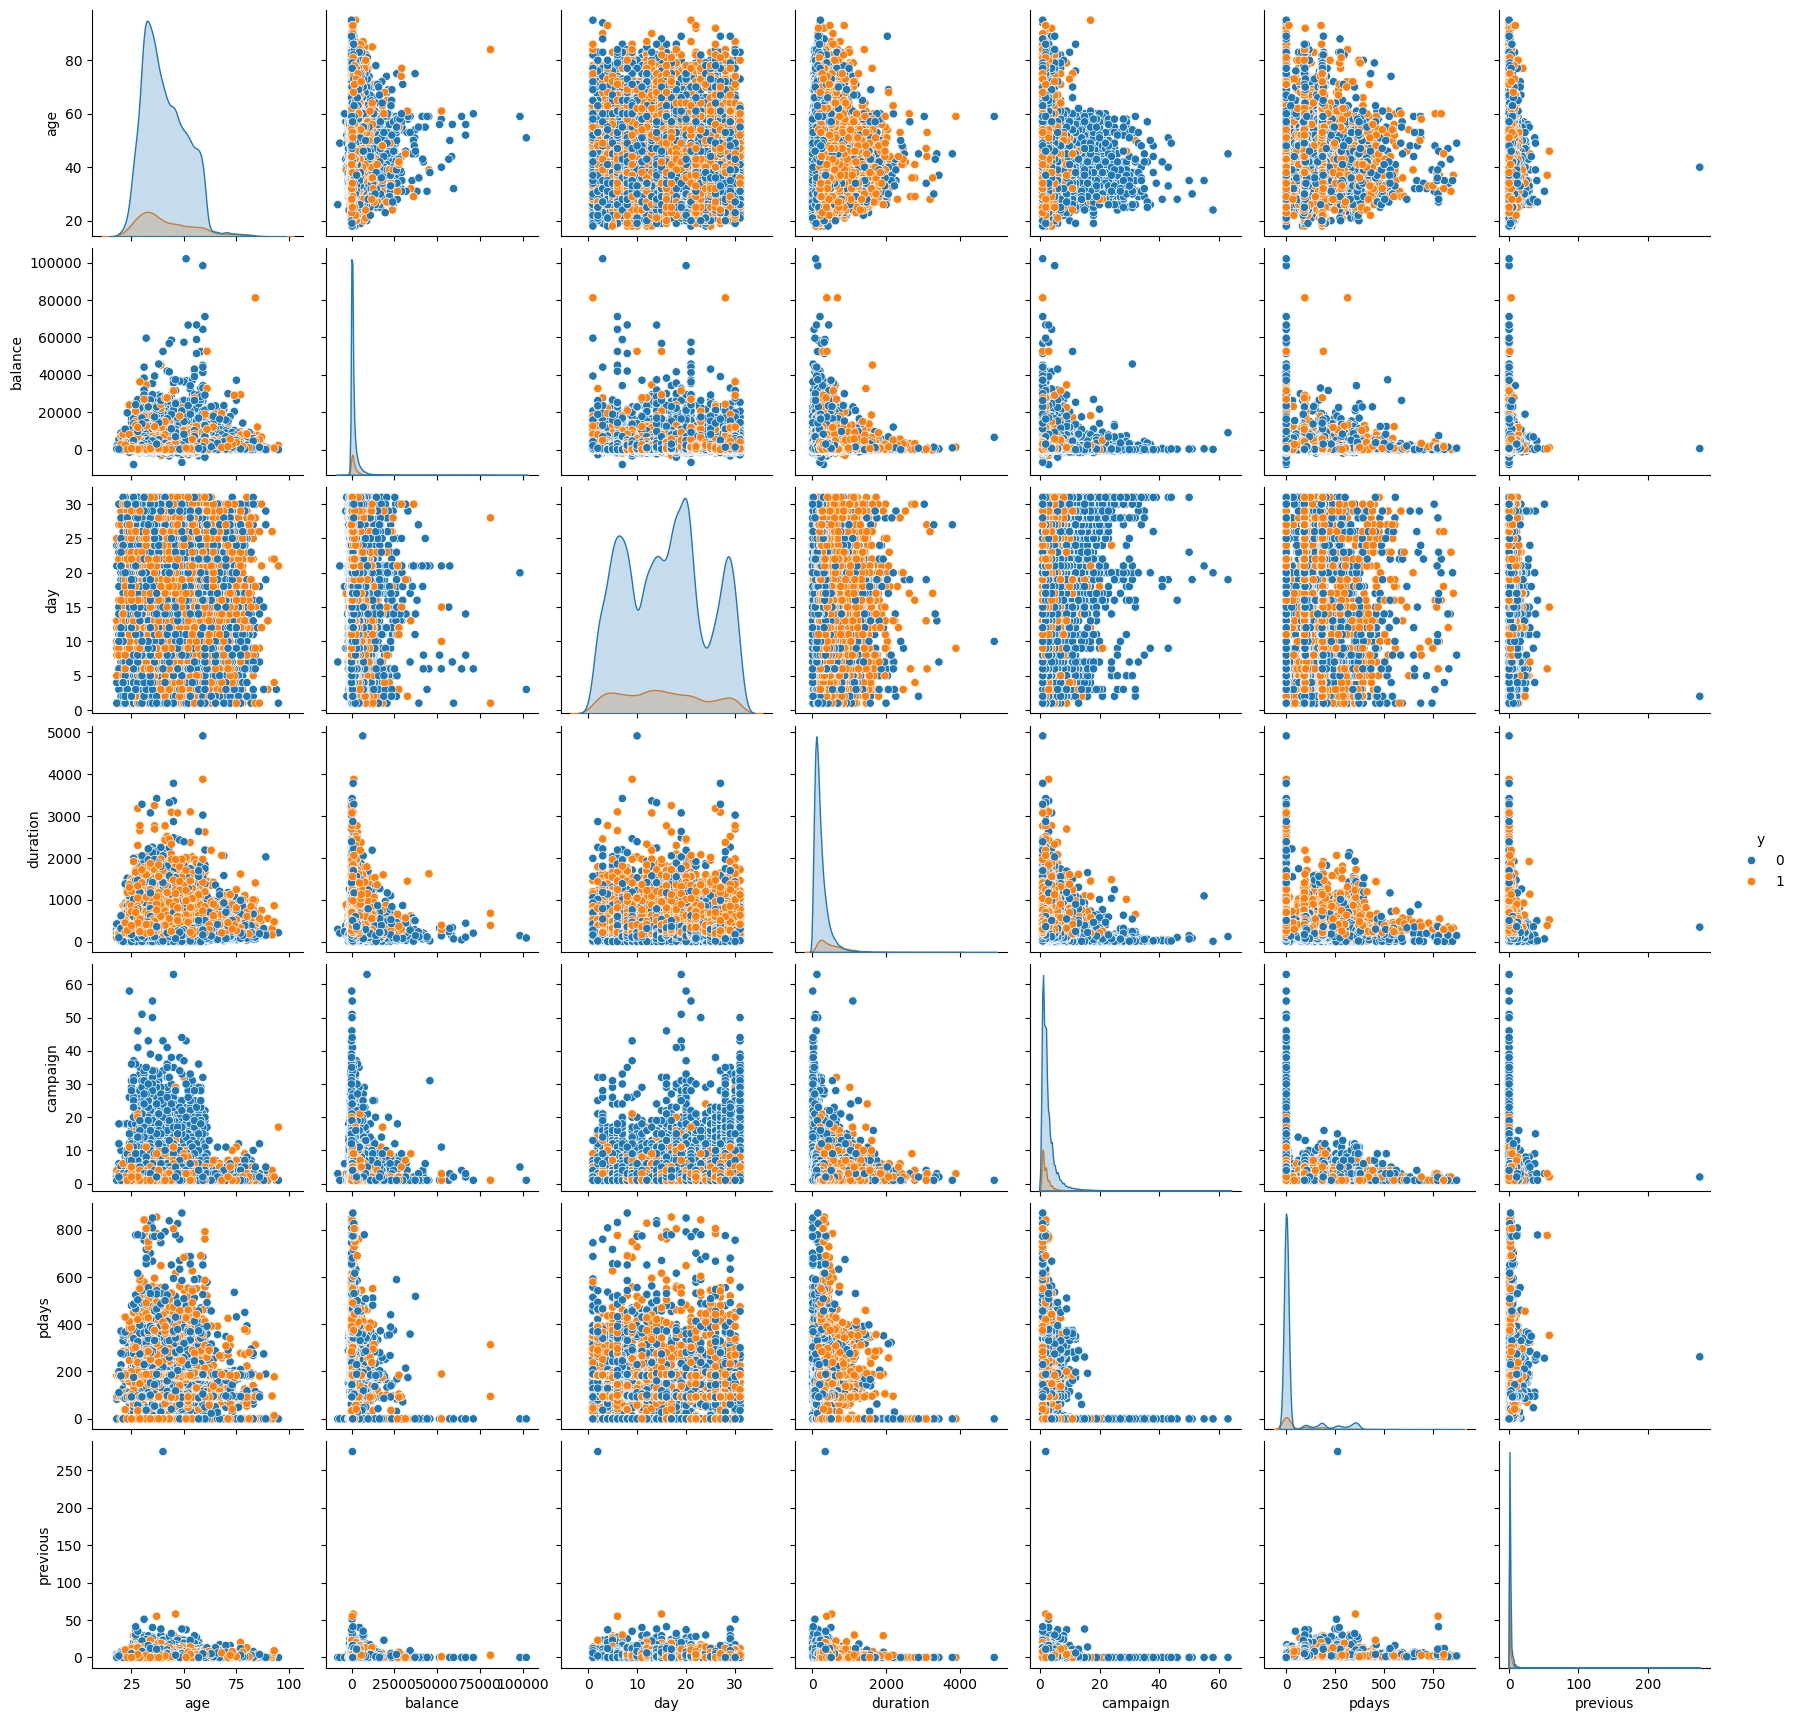

In [15]:
sns.pairplot(dfauxNum.toPandas(), kind = 'scatter', hue='y')
plt.show()

## **PIE GRAPHICS: BINARY VARIABLES**

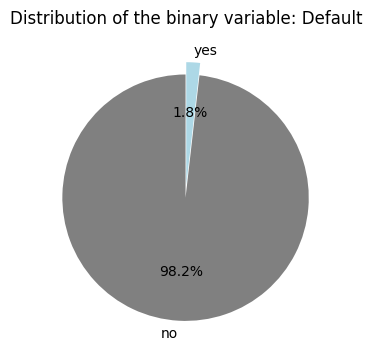

In [16]:
## We will draw [default, housing, loan] individually

##DEFAULT
explode = (0.1,0) #To generate relieve in yes 
colors = ['grey','lightblue']

plt.figure(figsize=(5,4))
cantBin = df01.groupby('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie',explode= explode, colors=colors, autopct = '%1.1f%%', startangle=90)
plt.title(f'Distribution of the binary variable: Default')
plt.ylabel('')
plt.show()

### **COMMENTS**
We can find a big desproportion in this variable, more than 98% of the variable locate in the no, meaning that almost no one of the dataset had creadit in default.

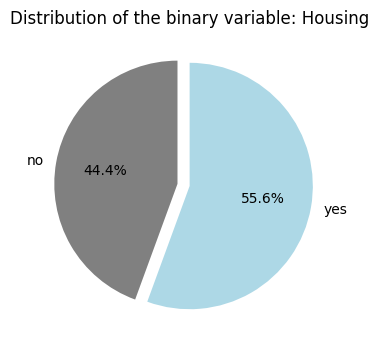

In [17]:
##HOUSING
explode = (0.1,0)  
colors = ['grey','lightblue']

plt.figure(figsize=(5,4))
cantBin = df01.groupby('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind='pie',explode= explode, colors=colors, autopct = '%1.1f%%', startangle=90)
plt.title(f'Distribution of the binary variable: Housing')
plt.ylabel('')
plt.show()

### **COMMENTS**
We can find a difference between this graphic and the last one, with housing we have a more balance answers, meaning that a lot of our clients to study have a housing loan.

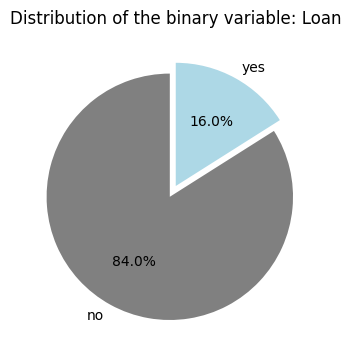

In [18]:
##LOAN
explode = (0.1,0)  
colors = ['grey','lightblue']

plt.figure(figsize=(5,4))
cantBin = df01.groupby('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(kind='pie',explode= explode, colors=colors, autopct = '%1.1f%%', startangle=90)
plt.title(f'Distribution of the binary variable: Loan')
plt.ylabel('')
plt.show()

### **COMMENTS**
We can find a desproportion in this variable, the most of the people doesn't have any personal loan.

## **MULTIDIMENSIONAL CATEGORICAL VARIABLES**

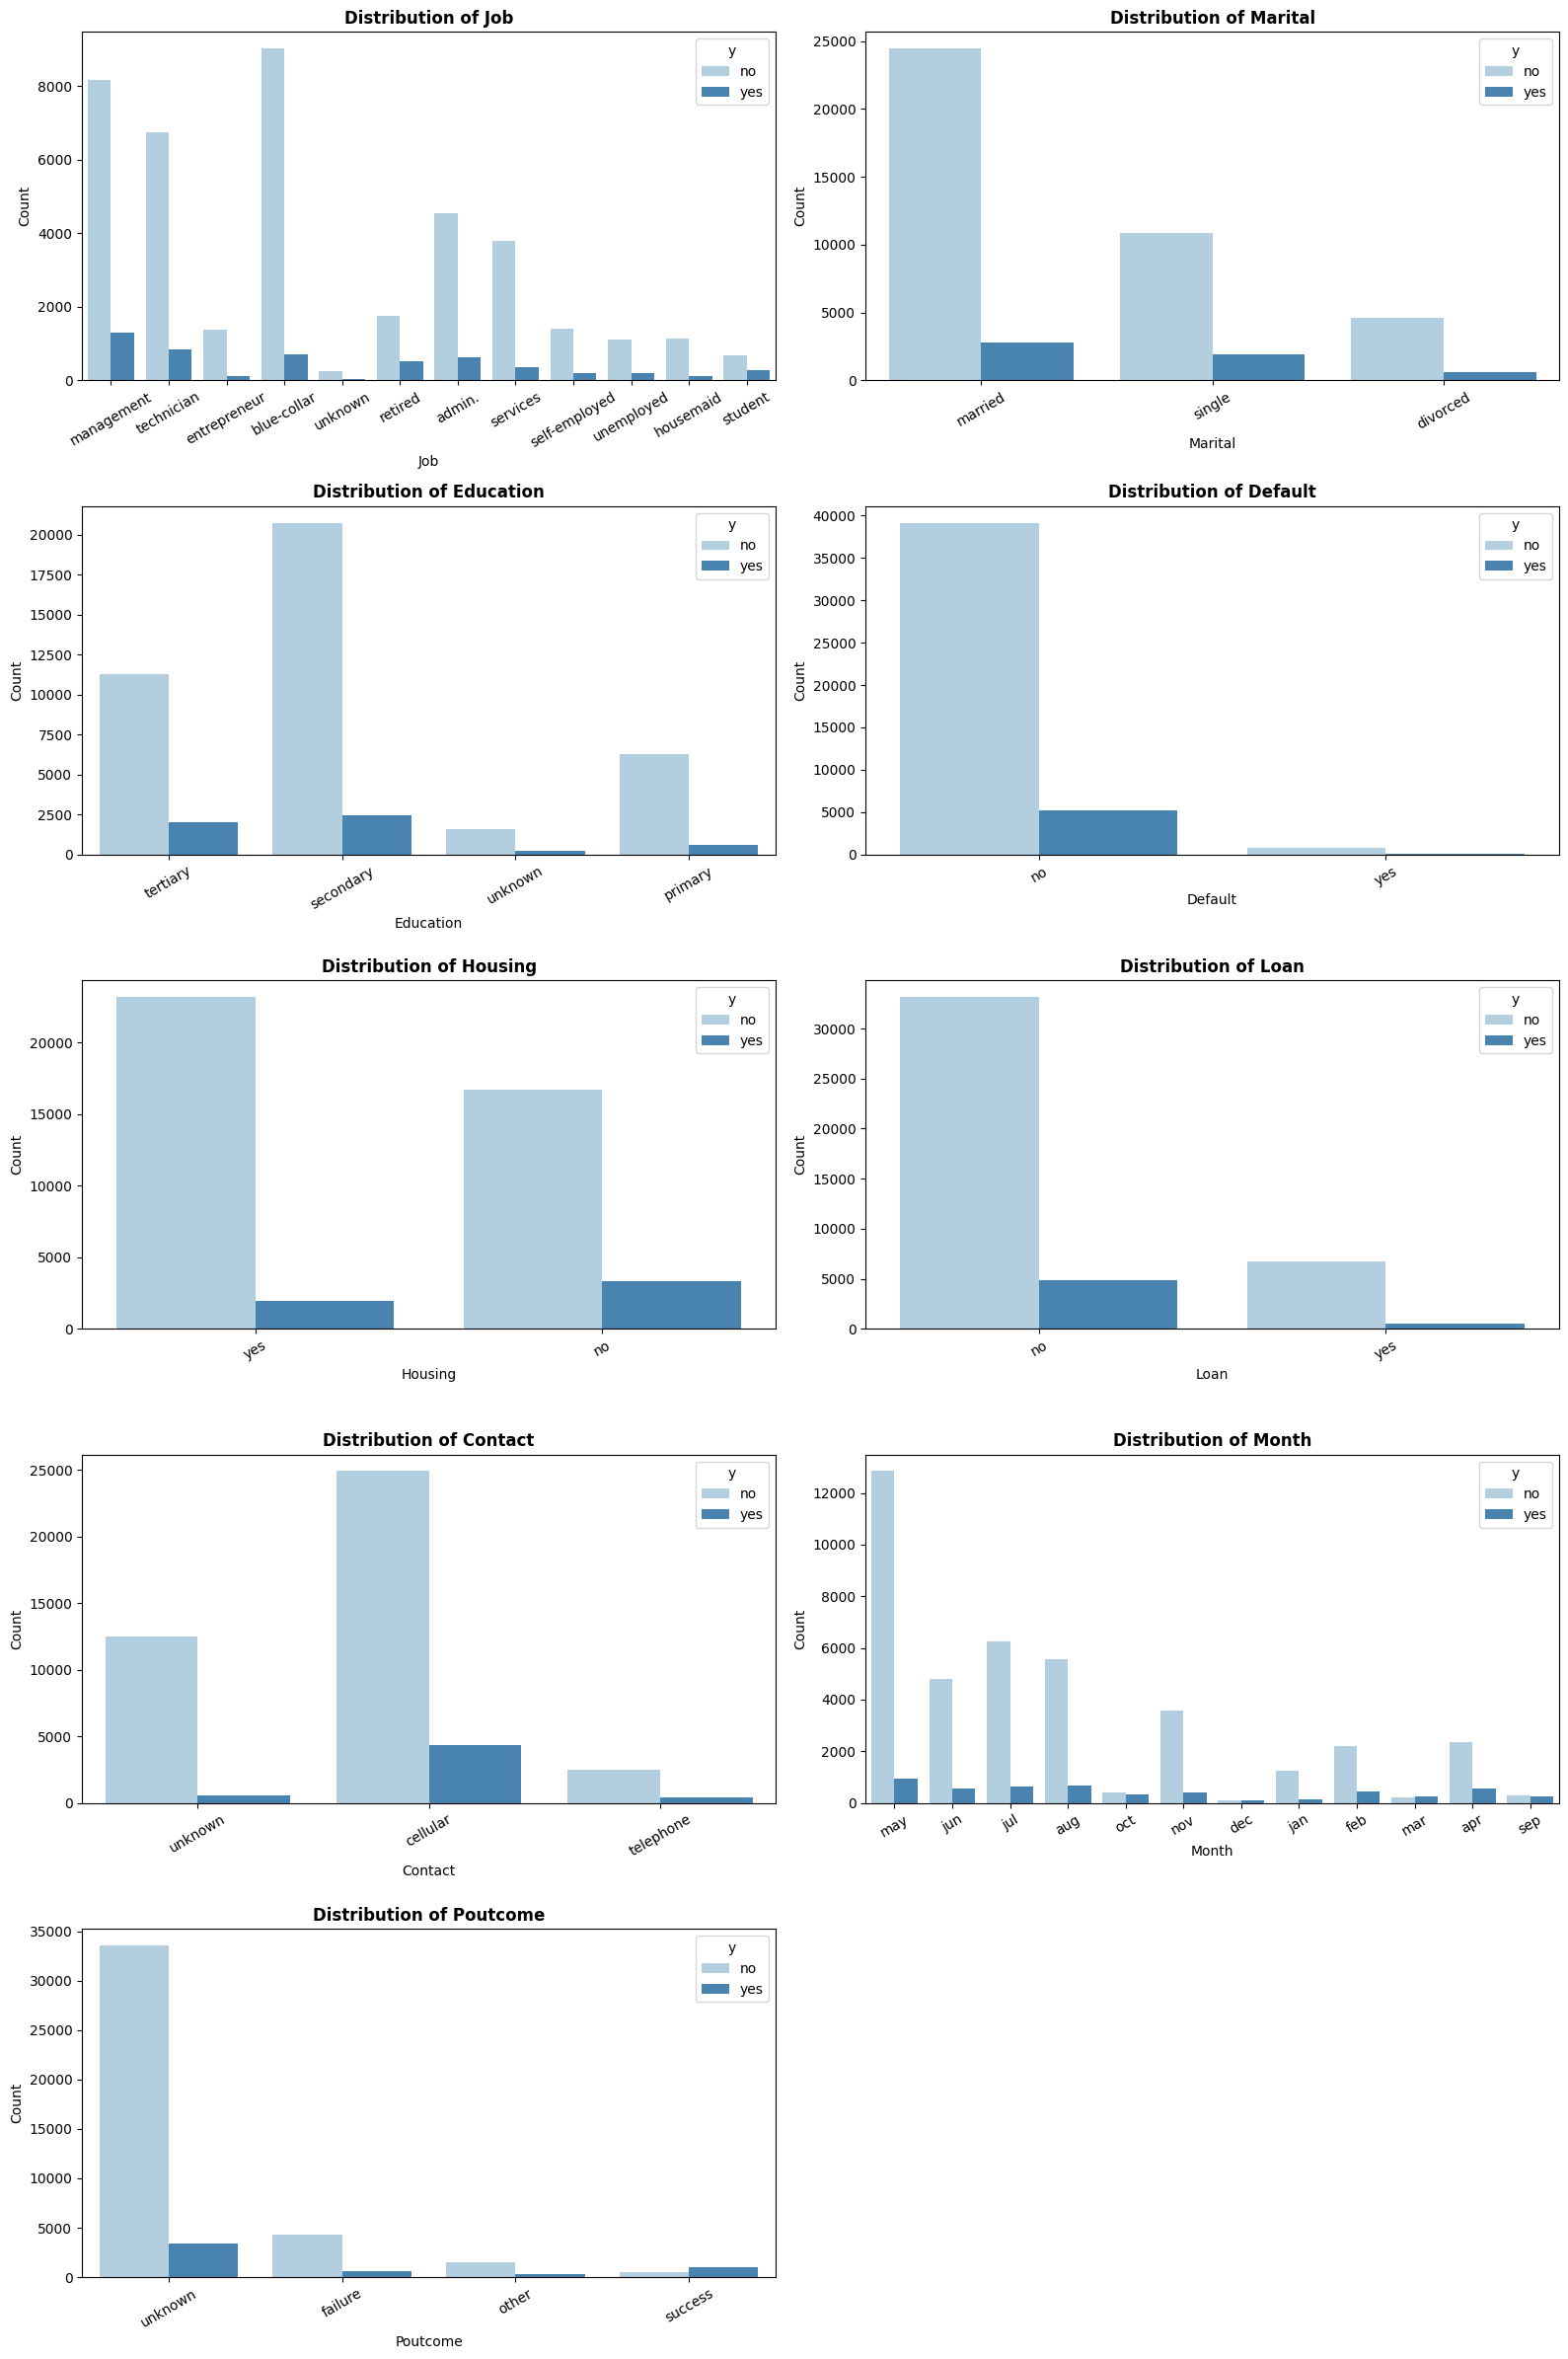

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your categorical variables
colCat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# 2. Convert to Pandas once to save cluster resources
df_pandas_cat = df01.toPandas()

# 3. Create a grid layout (5 rows, 2 columns perfectly fits up to 10 variables)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 24))

# Flatten the grid array to easily step through it
axes = axes.flatten()

# 4. Generate the frequency plots
for i, col_cat in enumerate(colCat):
    sns.countplot(
        x=col_cat, 
        data=df_pandas_cat, 
        hue='y',          # Splitting by target variable 'y' makes it incredibly analytical
        palette='Blues',  # Clean corporate presentation look
        ax=axes[i]
    )
    # Stylize titles and labels
    axes[i].set_title(f"Distribution of {col_cat.capitalize()}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col_cat.capitalize())
    axes[i].set_ylabel("Count")
    # Rotate long text labels (like job names) so they don't mash into each other
    axes[i].tick_params(axis='x', rotation=30)
# 5. Hide the 10th plot window since we only have 9 variables
axes[-1].set_visible(False)

# Optimize spacing across the layout panel
plt.tight_layout()
plt.show()

### **COMMENTS**

#### **1. Distribution of Job**
Observation: The dataset is heavily dominated by working-class and corporate positions, with the highest counts found in blue-collar, management, and technician fields. Conversely, categories like student, housemaid, and unemployed have very low representation.
While blue-collar workers are contacted the most, their conversion rate ("yes") is visually lower compared to categories like management or retired.

#### **2. Distribution of Marital**
Observation: married clients form the overwhelming majority of the individuals targeted in this campaign, followed by single individuals, with divorced individuals making up the smallest segment. The ratio of "yes" to "no" responses appears relatively consistent across all three familial statuses.

#### **3. Distribution of Education**
Observation: The vast majority of the targeted market has a secondary education level, followed by tertiary education. Clients with a primary education level are much less frequent, and a small sliver of the data contains an unknown education status.

#### **4. Distribution of Default**
Observation: There is an extreme, near-total imbalance in this feature. Almost the entire dataset consists of clients who do not have credit in default (no). The number of individuals with a history of credit default (yes) is visually negligible.

#### **5. Distribution of Housing**
Observation: The split between clients who have a housing loan (yes) and those who do not (no) is relatively balanced, though there are more clients with housing loans. Interestingly, the proportion of clients who subscribed to the term deposit ("yes") is visibly higher among those who do not carry a housing loan.

#### **6. Distribution of Loan**
Observation: The majority of the target demographic does not have a personal loan (no). Personal loan holders (yes) make up a small fraction of the data, and their conversion rate to the term deposit appears noticeably lower than those without personal loans.

#### **7. Distribution of Contact**
Observation: cellular communication is the dominant method used to contact clients. A massive portion of the dataset falls under unknown contact methods (likely missing data from older entries), while traditional landline telephone communication is rarely used.

#### **8. Distribution of Month**
Observation: Marketing campaign activity is highly seasonal. There is a massive spike in contacts during the month of may, followed by moderate activity during summer months (jun, jul, aug). In contrast, winter and spring months like dec, jan, and sep show minimal contact attempts, though these low-activity months often display higher relative conversion ratios.

#### **9. Distribution of Poutcome**
Observation: For the outcome of the previous marketing campaign, the vast majority of entries are classified as unknown. This correlates with your earlier numeric plots showing that most clients are entirely new prospects. Where a previous outcome is recorded, failure outnumbers success, though the success category shows an incredibly high conversion rate to a "yes" in the current campaign

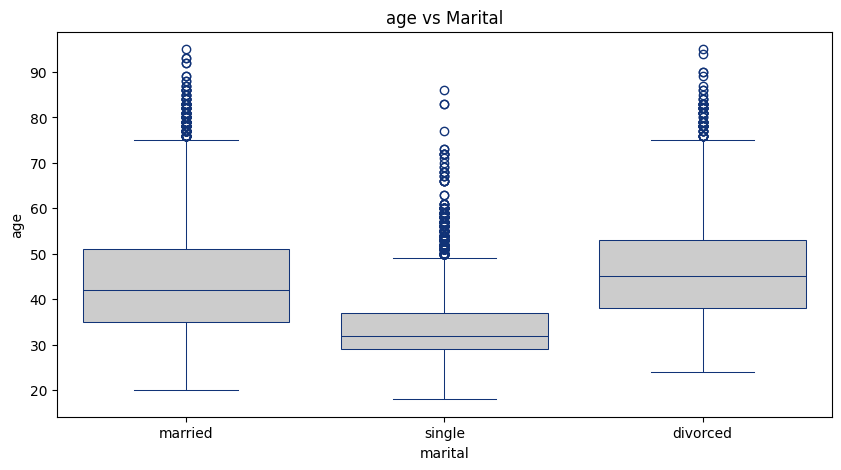

In [20]:
### The goal using this type of graphic is to notices tendencies and outlyeres of the variables
plt.figure(figsize=(10,5))
sns.boxplot(x='marital', y='age', color=".8", linecolor="#137", linewidth=0.75, data=df01.toPandas())
plt.title(f"age vs Marital")
plt.xlabel("marital")
plt.ylabel('age')
plt.show()

### **COMMENTS**
Observation: There is a clear and expected progression in age based on marital status groups.

The single group has the lowest median age (around 32 years old) and a highly compressed interquartile range (IQR) concentrated between roughly 28 and 37. It also features a tall vertical column of older outliers stretching up toward age 85+.

The married group has a visibly higher median age (around 42 years old) with a broader age spread, spanning primarily from 35 to 51.

The divorced group displays the highest median age of all three categories (around 45 years old), with its IQR shifting further up between roughly 38 and 53.

*Summary:* This visualization confirms a strong structural relationship between a client's age and their marital status, which makes intuitive demographic sense.

## **NULL VALUES**

In [21]:
for column in df01.columns:
    cantNull = df01.where(F.col(column).isNull()).count()
    print(f"'{column}' : {cantNull} null values")

'age' : 0 null values
'job' : 0 null values
'marital' : 0 null values
'education' : 0 null values
'default' : 0 null values
'balance' : 0 null values
'housing' : 0 null values
'loan' : 0 null values
'contact' : 0 null values
'day' : 0 null values
'month' : 0 null values
'duration' : 0 null values
'campaign' : 0 null values
'pdays' : 0 null values
'previous' : 0 null values
'poutcome' : 0 null values
'y' : 0 null values


## **DATA PREPARATION**

In [22]:
noPdays = df01.filter(F.col('pdays') == -1).count()

porcNoPdays = (noPdays/total)*100
print(f"Percentage of customers not previously contacted: {porcNoPdays:.2f}%")

# Pdays will be deleted because of the multicollinearity and de possible bias that the variable can introduc

Percentage of customers not previously contacted: 81.74%


In [23]:
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



In [24]:
## Is required to eliminate those outliers: data from 30 and more.
# Is calculate the amount of registers that are in this range of data.
limitePrevio = 30

cantLimitePrevio = df01.filter(F.col('previous') > limitePrevio).count()

print(f"Amount of data above 30 contacts: {cantLimitePrevio}")
#DEL 30 PARA ARRIBA SON OUTLIERS


Amount of data above 30 contacts: 12


In [25]:
df02 = df01.filter(F.col('previous') <= 30)

In [26]:
# Is eliminated "pdays"
df03 = df02.drop('pdays')

In [27]:
## Balance target variable: 
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')


cantMayor = dfMayorDependiente.count()
### Oversampling
dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

## Combine balance dataframes
df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [28]:
print(f"df04 have (after oversampling) = {df04.count()}")

df04 have (after oversampling) = 80201


In [29]:
## He show a table with the proportions

totalNw = df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("Porcentage", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentage|
+---+-----+-----------------+
|yes|40289|50.23503447587935|
| no|39912|49.76496552412065|
+---+-----+-----------------+



In [30]:
print(f"Number of records DF01 = {df01.count()}")
print(f"Number of records DF04 = {df04.count()}")

Number of records DF01 = 45211
Number of records DF04 = 80201


In [31]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [32]:
for column in df04.columns:
    cantNull = df04.where(F.col(column).isNull()).count()
    print(f"'{column}' : {cantNull} null values")

'age' : 0 null values
'job' : 0 null values
'marital' : 0 null values
'education' : 0 null values
'default' : 0 null values
'balance' : 0 null values
'housing' : 0 null values
'loan' : 0 null values
'contact' : 0 null values
'day' : 0 null values
'month' : 0 null values
'duration' : 0 null values
'campaign' : 0 null values
'previous' : 0 null values
'poutcome' : 0 null values
'y' : 0 null values


In [33]:
totalNw = df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("%", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|                %|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



## **CHARACTERISTICS CODIFICATION**

In [34]:
# One Hot Encoding
col_cat = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

stages = []

for col in col_cat:
    indexer = StringIndexer(inputCol=col, outputCol=col + 'x')

    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[col + '_oneHot'])
    stages += [indexer, encoder]

In [35]:
label = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')

stages += [label]

In [36]:
NumCol = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

ensInput = [c + '_oneHot' for c in col_cat] + NumCol

ensInput

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

In [37]:
ensVector = VectorAssembler(inputCols=ensInput, outputCol='features')
stages += [ensVector]

In [38]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=stages)
pipelineModel = pipeline.fit(df04)

pipelineModel.write().overwrite().save(path='pipeModel')
model = pipelineModel.transform(df04)

In [39]:
model.show(5)

26/05/25 22:19:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

In [40]:
df05 = model.select("label", "features")
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [41]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [42]:
df05.write.mode("overwrite").parquet("output.parquet")

In [43]:
#df06 = sparkS.read.parquet("/home/estudiante/output.parquet")
#df06.show(2)

## **SPARK MACHINE LEARNING MODELS**

In [44]:
# The dataset is divided in train and test data
trainData, testData = df05.randomSplit([.8, .2], seed=4321)

print(f"Train data amount: {trainData.count()}")
print(f"Test data amount: {testData.count()}")

Train data amount: 64234


[Stage 363:==========================================>              (3 + 1) / 4]

Test data amount: 15967


In [45]:
# The test data balance is verified 

distTest = testData.groupBy("label").count()

distTest = distTest.withColumn("%", distTest["count"]*100/testData.count())
distTest.show()

[Stage 369:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|                %|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



In [46]:
# The train data balance is verified 

distTrain = trainData.groupBy("label").count()

distTrain = distTrain.withColumn("%", distTrain["count"]*100/trainData.count())
distTrain.show()

[Stage 375:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|                %|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



In [47]:
## Confusion matrix function

def plotConfusionMat(confMatrix, subtitle):
    confMatrixPandas = confMatrix.toPandas() #---> Dataframe to pandas
    confMatrixPivot = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0) #---> Restructuration to create confusion matrix 
    plt.figure(figsize=(5,3))
    sns.heatmap(confMatrixPivot, annot=True, fmt='g', cmap= 'Blues')
    plt.suptitle(subtitle)
    plt.subplots_adjust(hspace=0.6)
    plt.tight_layout()
    plt.title('Confusion Matrix')
    plt.xlabel('Label prediction')
    plt.ylabel('Label')
    plt.show()

In [48]:
# ROC curve function

def plotROC(predictions, rocMetric, subtitle):
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1]) # Getting the probabilities for the positive class
    labels = predictions.select('label').rdd.map(lambda row: row['label']) #---> getting true labels
    fpr, tpr, thesholds = roc_curve(labels.collect(), probs.collect()) #---> calculating ROC using probabilities of the true labels
    
    # Graphicating ROC curve
    plt.figure(figsize=(8,4))
    plt.plot(fpr, tpr, color='grey', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--')
    plt.xlabel('False Positive Proportion')
    plt.ylabel('True Positive Proportion')
    plt.title('ROC curve')
    plt.suptitle(subtitle)
    plt.legend(loc='lower right')
    plt.show()


In [49]:
def plotROC_SVM(predictions, rocMetric, subtitle):
    # Check if 'probability' column exists; if not, fallback to 'rawPrediction'
    if 'probability' in predictions.columns:
        # For Logistic Regression / Trees (index 1 is the positive class probability)
        probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    else:
        # For SVM (index 1 is the raw distance score/margin for the positive class)
        probs = predictions.select('rawPrediction').rdd.map(lambda row: row['rawPrediction'][1])
        
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())

     # Graphicating ROC curve
    plt.figure(figsize=(8,4))
    plt.plot(fpr, tpr, color='grey', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--')
    plt.xlabel('False Positive Proportion')
    plt.ylabel('True Positive Proportion')
    plt.title('ROC curve')
    plt.suptitle(subtitle)
    plt.legend(loc='lower right')
    plt.show()


## **First model**: [Linear Regression](https://spark.apache.org/docs/latest/ml-classification-regression.html#logistic-regression)
#### - **Trained object creation**: LRmodel

In [50]:
from pyspark.ml.classification import LogisticRegression
LRinstance = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)

# Model fitting using Train data 
LRmodel = LRinstance.fit(trainData)

26/05/25 22:20:11 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

In [51]:
# Test data predictions
predLR = LRmodel.transform(testData)
predLR.select("label","prediction", "probability").show(5)

[Stage 391:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407799...|
|  0.0|       0.0|[0.80219726828946...|
|  0.0|       0.0|[0.92534178616341...|
|  0.0|       0.0|[0.91139649682633...|
+-----+----------+--------------------+
only showing top 5 rows



In [52]:
evaluatorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

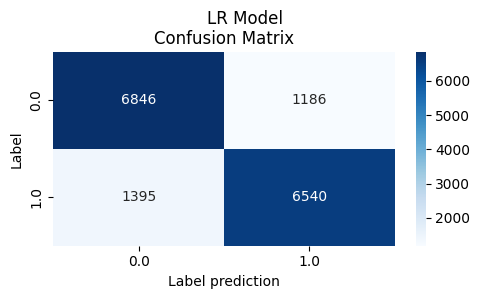

[Stage 401:==========================================>              (3 + 1) / 4]

Performance metrics results: Logistic Regression Model
Precision: 0.839 %
Recall: 0.838 %
F1 score: 0.838 %
Accuracy: 0.838 %


In [53]:
# Confusion Matrix creation
firstModel = "LR Model"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixLR, firstModel)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "accuracy"})
precisionLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "weightedPrecision"})
recallLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "f1"})

#Metrics print
print(f"Performance metrics results: Logistic Regression Model")
print(f"Precision: {round(precisionLR, 3)} %")
print(f"Recall: {round(recallLR, 3)} %")
print(f"F1 score: {round(f1ScoreLR, 3)} %")
print(f"Accuracy: {round(accuracyLR, 3)} %")

0.9142841127613052
areaUnderROC


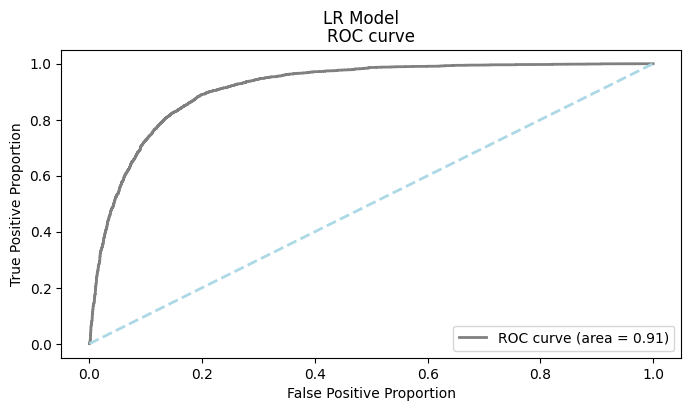

In [54]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocLR = evaluatorBinLR.evaluate(predLR)
print(rocLR)
print(evaluatorBinLR.getMetricName())

plotROC(predLR,rocLR, firstModel)

## **COMMENTS**

## **Second Model**: [Decision Tree](https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-classifier)

In [55]:
from pyspark.ml.classification import DecisionTreeClassifier
DTinstance = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modelDT = DTinstance.fit(trainData)

In [56]:
# Test data predictions
predDT = modelDT.transform(testData)
predDT.select("label", "prediction", "probability").show(10)

[Stage 430:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.91507246376811...|
|  0.0|       0.0|[0.91507246376811...|
|  0.0|       0.0|[0.91507246376811...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.59899026325279...|
|  0.0|       0.0|[0.83432488360062...|
+-----+----------+--------------------+
only showing top 10 rows



In [57]:
evaluatorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

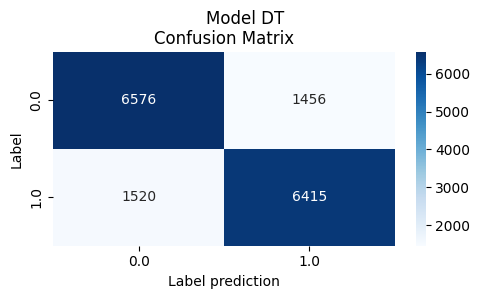

[Stage 440:==========================================>              (3 + 1) / 4]

Performance metrics results: Decision tree Model
Precision: 0.814 %
Recall:    0.814 %
Accuracy:  0.814 %
f1Score:  0.814 %


In [58]:
# Confusion Matrix creation
secondModel = "Model DT"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixDT, secondModel)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "accuracy"})
precisionDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "weightedPrecision"})
recallDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Decision tree Model")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall:    {round(recallDT,3)} %")
print(f"Accuracy:  {round(accuracyDT,3)} %")
print(f"f1Score:  {round(f1ScoreDT,3)} %")

0.691170439539887
areaUnderROC


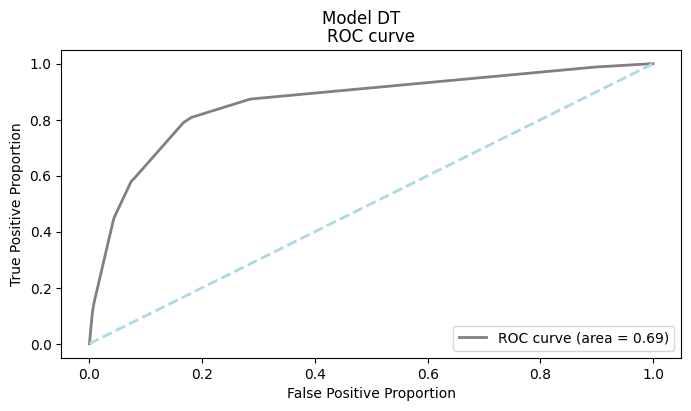

In [59]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocDT = evaluatorBinDT.evaluate(predDT)
print(rocDT)
print(evaluatorBinDT.getMetricName())

plotROC(predDT,rocDT,secondModel)

## **Third Model**: [Random Forest](https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-classifier)

In [60]:
from pyspark.ml.classification import RandomForestClassifier
RFinstance = RandomForestClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modelRF = RFinstance.fit(trainData)

In [61]:
# Test data predictions
predRF = modelRF.transform(testData)
predRF.select("label", "prediction", "probability").show(10)

[Stage 469:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.72277191138371...|
|  0.0|       0.0|[0.54618571614868...|
|  0.0|       0.0|[0.76500739645446...|
|  0.0|       0.0|[0.83638357865010...|
|  0.0|       0.0|[0.80575790947112...|
|  0.0|       0.0|[0.75391704481843...|
|  0.0|       0.0|[0.75050371437750...|
|  0.0|       0.0|[0.74517492929391...|
|  0.0|       1.0|[0.46251476955069...|
|  0.0|       0.0|[0.68990801945437...|
+-----+----------+--------------------+
only showing top 10 rows



In [62]:
evaluatorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

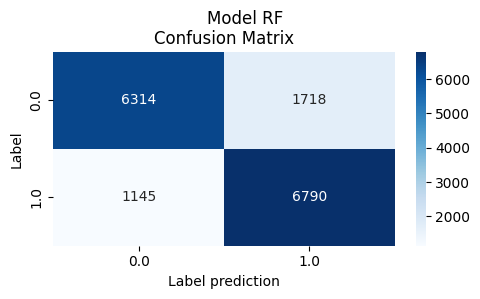

[Stage 479:==========================================>              (3 + 1) / 4]

Performance metrics results: Random Forest Model
Precision: 0.822 %
Recall:    0.821 %
Accuracy:  0.821 %
f1Score:  0.821 %


In [63]:
# Confussion Matrix creation
thirdModel = "Model RF"
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixRF, thirdModel)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "accuracy"})
precisionRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "weightedPrecision"})
recallRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "weightedRecall"})
f1ScoreRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Random Forest Model")
print(f"Precision: {round(precisionRF,3)} %")
print(f"Recall:    {round(recallRF,3)} %")
print(f"Accuracy:  {round(accuracyRF,3)} %")
print(f"f1Score:  {round(f1ScoreRF,3)} %")

0.8942950315938515
areaUnderROC


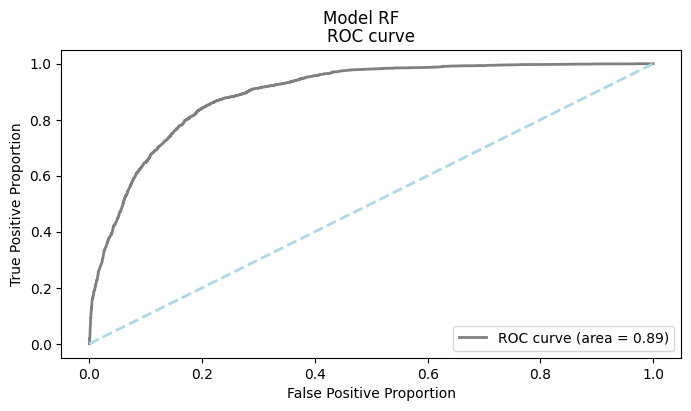

In [64]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocRF = evaluatorBinRF.evaluate(predRF)
print(rocRF)
print(evaluatorBinRF.getMetricName())

plotROC(predRF,rocRF,thirdModel)

## **Fourth Model**: [Gradient Boosted Tree (GBT)](https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier)

In [65]:
from pyspark.ml.classification import GBTClassifier
GBTinstance = GBTClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modelGBT = GBTinstance.fit(trainData)

In [66]:
# Test data predictions
predGBT = modelGBT.transform(testData)
predGBT.select("label", "prediction", "probability").show(10)

[Stage 698:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.92393669660394...|
|  0.0|       0.0|[0.89799729361442...|
|  0.0|       0.0|[0.91375463712964...|
|  0.0|       0.0|[0.94468169672351...|
|  0.0|       0.0|[0.94424142078640...|
|  0.0|       0.0|[0.90001144562502...|
|  0.0|       0.0|[0.91498495379947...|
|  0.0|       0.0|[0.90440085021371...|
|  0.0|       0.0|[0.63734218784756...|
|  0.0|       0.0|[0.89881419067339...|
+-----+----------+--------------------+
only showing top 10 rows



In [67]:
evaluatorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

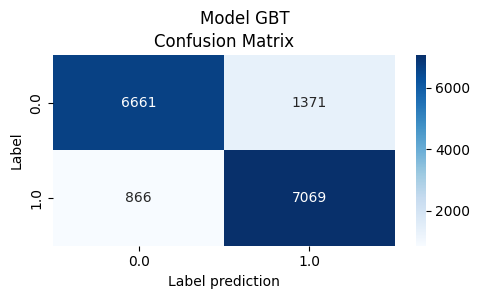

[Stage 708:==========================================>              (3 + 1) / 4]

Performance metrics results: Gradient Boosting Tree Model
Precision: 0.861 %
Recall:    0.86 %
Accuracy:  0.86 %
f1Score:  0.86 %


In [68]:
# Confusion Matrix creation
fourthModel = "Model GBT"
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixGBT, fourthModel)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "accuracy"})
precisionGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "weightedPrecision"})
recallGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "weightedRecall"})
f1ScoreGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Gradient Boosting Tree Model")
print(f"Precision: {round(precisionGBT,3)} %")
print(f"Recall:    {round(recallGBT,3)} %")
print(f"Accuracy:  {round(accuracyGBT,3)} %")
print(f"f1Score:  {round(f1ScoreGBT,3)} %")

0.9272121030685073
areaUnderROC


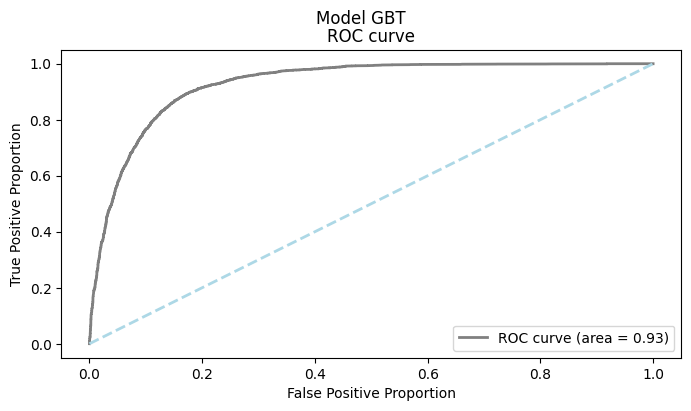

In [69]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocGBT = evaluatorBinGBT.evaluate(predGBT)
print(rocGBT)
print(evaluatorBinGBT.getMetricName())

plotROC(predGBT,rocGBT,fourthModel)

## **Fifth Model**: [Support Vector Machine (SVM)](https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-support-vector-machine)

In [ ]:
from pyspark.ml.classification import LinearSVC
SVMinstance = LinearSVC(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modelSVM = SVMinstance.fit(trainData)

In [ ]:
# Test data predictions
predSVM = modelSVM.transform(testData)
predSVM.select("label", "prediction", "rawprediction").show(10)

In [ ]:
evaluatorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

In [ ]:
# Confusion Matrix creation
fifthModel = "Model SVM"
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixSVM, fifthModel)

# Calculus of the model LR metrics using the multiclass evaluator
accuracySVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "accuracy"})
precisionSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "weightedPrecision"})
recallSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "weightedRecall"})
f1ScoreSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Support Vector Machine Model")
print(f"Precision: {round(precisionSVM,3)} %")
print(f"Recall:    {round(recallSVM,3)} %")
print(f"Accuracy:  {round(accuracySVM,3)} %")
print(f"f1Score:  {round(f1ScoreSVM,3)} %")

In [ ]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocSVM = evaluatorBinSVM.evaluate(predSVM)
print(rocSVM)
print(evaluatorBinSVM.getMetricName())

plotROC_SVM(predSVM,rocSVM,fifthModel)

### Comentarios
-----

## **MODELS EVALUATION**

In [ ]:
# General data
modelos  = ['LogisticRegression', 'DecisionTree', 'GBT','SVM', 'Random Forest' ]
accuracy = [accuracyLR, accuracyDT,accuracyGBT, accuracySVM, accuracyRF]
f1Score  = [f1ScoreLR, f1ScoreDT, f1ScoreGBT, f1ScoreSVM,f1ScoreRF]
curvaROC = [rocLR, rocDT,rocGBT, rocSVM,rocRF]

# Sort the values
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# bars lenght
longitud = 0.2

# horizontal bars
posHorizontal = np.arange(len(modelos))

# --- COLOR CUSTOMIZATION (Blue and Greys) ---
# 'steelblue' provides a clean corporate blue contrast
# '#4d4d4d' is a strong dark grey
# '#b3b3b3' is a clean light grey
barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy', color='steelblue')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score', color='#4d4d4d')
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC', color='#b3b3b3')

# CGraphic configuration
plt.ylabel('Modelos')
plt.xlabel('Valor de la Métrica')
plt.title('Models Performance')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))

# legend with the metrics
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

#print
plt.show()

## **Model Evaluation Comments**
**Top Performers:** The Gradient Boosting Tree (GBT), Support Vector Machine (SVM), and Logistic Regression emerge as the top-performing models in this classification task.

**Metric Convergence:** While all five models display highly competitive and nearly identical baselines for Accuracy and F1-Score (hovering around 82% to 85%), they diverge significantly when evaluating class separation.

**The ROC Differentiator:** GBT, SVM, and Logistic Regression drastically outperform the standalone Decision Tree and Random Forest models in terms of their ROC-AUC values (exceeding 0.90). This indicates that these three architectures possess a superior ability to distinguish between clients who will subscribe to the term deposit and those who will not, minimizing false positives and optimizing true positive detection rates.

## **FINAL CONCLUSIONS**

### **Conclusion 1 — Call Duration is the Decisive Conversion Signal**
Among all variables analyzed, duration shows the strongest correlation with subscription (r = 0.39), and the boxplots confirm it visually: clients who subscribed had significantly longer and wider-ranging call durations. This means the depth of the conversation — not how many times a client is called or their demographic profile — is the most reliable indicator of whether they will accept the term deposit offer.

### **Conclusion 2 — Gradient Boosted Trees is the Optimal Model for This Use Case**
While all five models converge at similar Accuracy and F1-Scores (~82–85%), GBT consistently leads in ROC-AUC (>0.90), alongside Logistic Regression and SVM. In a bank marketing context this metric matters most, because a higher AUC means fewer resources wasted calling clients who will say no. Combined with the oversampling strategy applied during preprocessing, GBT proves to be the most robust choice for predicting term deposit subscription at scale.

In [ ]:
sparkS.stop()